# Set Up
<ol>
    <li> Implement <u>at least</u> two NMF algorithms </li> <!--- Look into alternatives for themethod. --->
    <ul>
        <li>Specify the loss function (MINIMIZATION)</li>
        <li>Specify the optimization method</li>
    </ul>
    <li>Analyze robustness</li>
    <ul>
        <li>Minor preprocessing</li>
        <li>Noise (requires demonstration)</li>
        <li>Clearly show relative robustnesses</li> <!--- will require research--->
    </ul>
</ol>

## Libraries
Scikit learn can be used for evaluation and NOT the implementation of the algorithm. Three following econstruction errors are suggested, of which only 1 is mandatory:
<ol>
    <li>Relative Reconstruction Errors(RRE)$$ RRE = \frac{||\hat V - WH||_F}{||\hat V||_F}$$
    </li>
    <li> Average Accuracy $$Acc(Y,Y_{pred}) = \frac{1}{n}\sum^n_{i=1}1\{Y_{pred}(i)==Y(i)\}$$  
    <\li>
    <li> Normalized Mutual Information (NMI)$$ NMI(Y,Y_{pred}) = \frac{2*I(Y,Y_{pred})}{H(Y)+H(Y_{pred})}$$
    <\li>

# Libraries

In [27]:
# Libraries
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

# Loading images

In [28]:
def load_data_AR(root='data/CroppedAR', reduce=3):
    """ 
    Load AR dataset to numpy array.
    
    Args:
        root: path to AR dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []
    
    for fname in os.listdir(root):
        
        if not fname.endswith('.bmp'):
            continue
        
        # get label.
        label = int(fname[2:5])
        if fname[0] == 'W': # start from 50
            label += 50
        
        # load image.
        img = Image.open(os.path.join(root, fname))
        img = img.convert('L') # grey
        
        # reduce computation complexity.
        img = img.resize([s//reduce for s in img.size])
   
        # TODO: preprocessing.
        
        # convert image to numpy array.
        img = np.asarray(img).reshape((-1,1))
        
        # collect data and label.
        images.append(img)
        labels.append(label)
        
    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)
    
    return images, labels

In [29]:
def load_data(root='data/CroppedYaleB', reduce=4):
    """ 
    Load ORL (or Extended YaleB) dataset to numpy array.
    
    Args:
        root: path to dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []

    for i, person in enumerate(sorted(os.listdir(root))):
        
        if not os.path.isdir(os.path.join(root, person)):
            continue
        
        for fname in os.listdir(os.path.join(root, person)):    
            
            # Remove background images in Extended YaleB dataset.
            if fname.endswith('Ambient.pgm'):
                continue
            
            if not fname.endswith('.pgm'):
                continue
                
            # load image.
            img = Image.open(os.path.join(root, person, fname))
            img = img.convert('L') # grey image.

            # reduce computation complexity.
            img = img.resize([s//reduce for s in img.size])
            shape = img.size

            # TODO: preprocessing.

            # convert image to numpy array.
            img = np.asarray(img).reshape((-1,1))
            
            
            # collect data and label.
            images.append(img)
            labels.append(i)
            
    
    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)

    return images, labels, shape

# STEPS
1. Preprocessing
2. NMF Implementations
3. Robustness Evaluations

In [30]:
def calc_cost(X,P,Q):
    c = 1/n*np.sum(s)
    return c

In [31]:
# Image Processing
def initialize(X,rs = 1,K=2):
    # initialize 
    N,M = X.shape
    K = 2
    rng = np.random.RandomState(rs)
    P = rng.rand(N,K)
    Q = rng.rand(M,K)
    return P,Q

In [32]:
# L2 Multiplicative Updater
def L2mu(R, P, Q, steps):
    Q = Q.T
    for step in range(steps):
        Pu = P*(R.dot(Q.T))/(P.dot(Q).dot(Q.T))
        Qu = Q*(Pu.T.dot(R)/(Pu.T.dot(Pu).dot(Q)))
        e_P = np.sqrt(np.sum((Pu-P)**2, axis=(0,1)))/P.size
        e_Q = np.sqrt(np.sum((Qu-Q)**2, axis=(1,0)))/Q.size
        if e_P<0.001 and e_Q<0.001:
            #print("step is:",step)
            break
        P = Pu
        Q = Qu
    return P, Q.T    

In [33]:
def calc_d(X,P,Q):
    d = []
    for i in range(Q.shape[0]):
        tmp = 1/np.linalg.norm(X[:,i] - P.dot(Q[i,:]))
        d.append(tmp)
    d = np.asanyarray(d)
    return np.diag(d)

def L21mu(R,P,Q,steps):
    Q = Q.T
    D = calc_d(R,P,Q.T)
    for step in range(steps):
        Pu = P*(R.dot(D.dot(Q.T)))/(P.dot(Q.dot(D.dot(Q.T))))
        Qu = Q*(Pu.T.dot(R.dot(D)))/(Pu.T.dot(Pu.dot(Q.dot(D))))
        e_P = np.sqrt(np.sum((Pu-P)**2, axis=(0,1)))/P.size
        e_Q = np.sqrt(np.sum((Qu-Q)**2, axis=(1,0)))/Q.size
        if e_P<0.001 and e_Q<0.001:
            #print("step is:",step)
            break
        P = Pu
        Q = Qu
    return P, Q.T  

In [34]:
def calc_w(R,P,Q,eps = 0.001):
    w = ((R - P.dot(Q))**2 + eps**2)**0.5
    return w

def L1mu(R,P,Q,steps):
    Q = Q.T
    W = calc_w(R,P,Q)
    for step in range(steps):
        Pu = P*((R*W).dot(Q.T))/(((P.dot(Q))*W).dot(Q.T))
        Qu = Q*(Pu.T.dot((R*W)))/(Pu.T.dot(((Pu.dot(Q))*W)))
        e_P = np.sqrt(np.sum((Pu-P)**2, axis=(0,1)))/P.size
        e_Q = np.sqrt(np.sum((Qu-Q)**2, axis=(1,0)))/Q.size
        if e_P<0.001 and e_Q<0.001:
            #print("step is:",step)
            break
        P = Pu
        Q = Qu
    return P, Q.T  

In [35]:
def plot_p(p_estimate, model, n, RRE, K=2, shape=(48,42)):
    plt.figure(figsize=(6, 3))
    plt.suptitle("learned basises from "+ model +" with "+ n +" NMF", size=16)
    print('The RRE for %s is %f' % (model, RRE))
    for i in range(K):
        plt.subplot(1, K, i+1)
        plt.imshow(p_estimate[:,i].reshape(shape), cmap=plt.cm.gray)
        plt.xticks(())
        plt.yticks(())
    plt.show()
    

## Measuring the Evaluation Metrics
<ul><li> RRE </li>
    <li> Acc </li>
    <li> NMI </li>

In [36]:
# RRE
def RRE(V_hat, metrics,n, steps=100):
    d ={}
    P,Q = initialize(X)
    possible = [L21mu, L1mu,L2mu]
    for model in metrics:
        if model in possible:
            W, H = possible(X,P,Q,steps)
            RRE = np.linalg.norm(V_hat - W.dot(H.T)) / np.linalg.norm(V_hat)
            plot_p(W, 'L2mu', RRE2)
            d['L2mu'] = [W,H,RRE2]

    return d

# Noise

In [37]:
def add_noise(x, dist,scale):
    if dist =="gaus":
        noise = np.random.randn(x.shape[0],x.shape[1])*scale
        noisy_x = noise + x
    if dist =="laplace":
        noise = np.random.laplace(size=(x.shape[0],x.shape[1]))*scale
        noisy_x = noise + x  
    return noisy_x, noise

In [38]:
import random

def add_block(X,shape,r):
    
    r = min(r,min(shape))
    
    m = X.shape[1]
    n = X.shape[0]
    X = X.reshape(*shape, m)
    
    X_final = np.zeros(X.shape)
    one_final = np.ones(X.shape)
    for img in range(m):
        random.seed(img)
        i,j = random.randint(0,shape[0]-r), random.randint(0,shape[1]-r)

        block = np.zeros((r,r))
        X_tmp = np.matrix.copy(X[:,:,img])
        X_tmp[i:i+r,j:j+r] = block
        one_tmp = np.ones(shape)
        one_tmp[i:i+r, j:j+r]= block
        
        X_final[:,:,img] = X_tmp
        one_final[:,:,img] = one_tmp
    
    X_final = X_final.reshape(n,m)
    one_final = one_final.reshape(n,m)
    return X_final, one_final

#aX_final, aone_final = add_block(X,(48,42), r=20)

In [59]:
def add_sp(X, shape, r):
    '''
        X = n*m matrix
        shape = the shape of the dataset
        r = the proportion of the image to block.
    '''
    X_final = np.zeros(X.shape)
    one_final = np.zeros(X.shape)
#     m = X.shape[1]
#     n = X.shape[0]
#     X = X.reshape(*shape, m)
    
#     X_final = np.zeros(X.shape)
#     one_final = np.ones(X.shape)
#     for img in range(m):
#         random.seed(img)
#         i,j = random.randint(0,shape[0]-r), random.randint(0,shape[1]-r)

#         block = np.zeros((r,r))
#         X_tmp = np.matrix.copy(X[:,:,img])
#         X_tmp[i:i+r,j:j+r] = block
#         one_tmp = np.ones(shape)
#         one_tmp[i:i+r, j:j+r]= block
        
#         X_final[:,:,img] = X_tmp
#         one_final[:,:,img] = one_tmp
    for i,col in enumerate(X.T):
        tmp = np.random.choice(2,size=len(col), p=[r,  1-r])
        X_final[:,i] = col*tmp
        one_final[:,i] = tmp
    
    return X_final, one_final

[[  0. 142. 196. ...  80.   0.   0.]
 [  4. 156.   0. ...  70.   4.  96.]
 [  4. 195.   0. ...  69.   5.  92.]
 ...
 [ 95.   0.   0. ...  10.   0.  15.]
 [106.   5.   0. ...  12.   0.   0.]
 [108.   0.   6. ...   0.   0.   0.]]


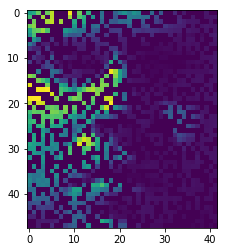

In [64]:
Q,W = add_sp(X, shape, 0.5)
print(Q)
plt.figure()
plt.imshow(Q[:,1].reshape(48,42))
plt.show()

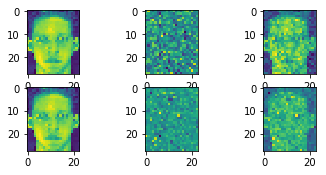

In [39]:
img = Image.open('data/ORL/s1/1.pgm')
img = img.resize([s//4 for s in img.size])
img = np.asarray(img)
scale = 20
#for i in range(3):
#plt.subplot("".join(['13',str(i)]))
plt.subplot('331')
plt.imshow(img)

plt.subplot('332')
noisy_img, noise = add_noise(img, 'gaus',scale)
plt.imshow(noise)

plt.subplot('333')
plt.imshow(noisy_img) 

plt.subplot('334')
plt.imshow(img)

plt.subplot('335')
noisy_img, noise = add_noise(img, 'laplace',scale)
plt.imshow(noise)

plt.subplot('336')
plt.imshow(noisy_img) 

plt.show()

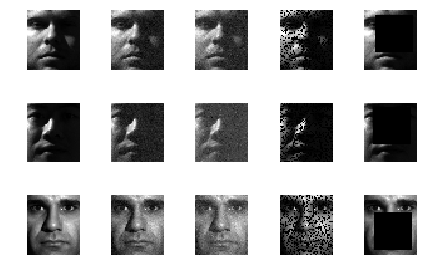

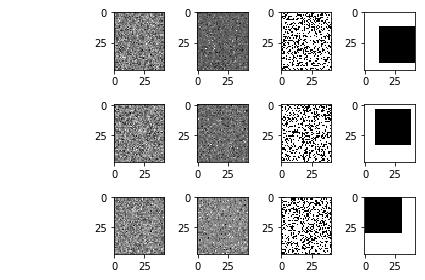

In [199]:

xgaus, noisegaus = add_noise(X, 'gaus',10)
xlaplace, noiselaplace = add_noise(X, 'laplace',10)
xsp, noisesp = add_sp(X,shape,.30)
xblocked, noiseblock = add_block(X,(48,42),30)

fig, axes = plt.subplots(3,5)


for i,person in enumerate([1,100,500]):
    axes[i,0].imshow(X[:,person].reshape(48,42), cmap='gray')
    axes[i,0].axis('off')
    axes[i,1].imshow(xgaus[:,person].reshape(48,42), cmap='gray')
    axes[i,1].axis('off')
    axes[i,2].imshow(xlaplace[:,person].reshape(48,42), cmap='gray')
    axes[i,2].axis('off')
    axes[i,3].imshow(xsp[:,person].reshape(48,42), cmap='gray')
    axes[i,3].axis('off')
    axes[i,4].imshow(xblocked[:,person].reshape(48,42), cmap='gray')
    axes[i,4].axis('off')
plt.tight_layout()

plt.savefig('noisyfaces.jpg')
plt.show(fig)

fig1, axes = plt.subplots(3,5)
for i in range(3):
    axes[i,0].axis('off')
    axes[i,1].imshow(noisegaus[:,i].reshape(48,42), cmap='gray')
    axes[i,2].imshow(noiselaplace[:,i].reshape(48,42), cmap='gray')
    axes[i,3].imshow(noisesp[:,i].reshape(48,42), cmap='gray')
    axes[i,4].imshow(noiseblock[:,i].reshape(48,42), cmap='gray') 
plt.savefig('noise.png')
plt.tight_layout()
plt.show()

In [143]:
os.getcwd()

'/media/taleni/MAIN/Uni/COMP5328/Assignment'

# Evaluation

In [40]:
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.metrics import normalized_mutual_info_score

def assign_cluster_label(H, Y):
    kmeans = KMeans(n_clusters=len(set(Y))).fit(H)
    Y_pred = np.zeros(Y.shape)
    for i in set(kmeans.labels_):
        ind = kmeans.labels_ == i
        Y_pred[ind] = Counter(Y[ind]).most_common(1)[0][0] # assign label.
    return Y_pred

# Putting it all together

In [128]:
# Loading data
X,Y,shape = load_data(root='data/CroppedYaleB', reduce=4)
#X,Y,shape = load_data(root='data/ORL', reduce=2)
# size = (48,42)|
# size = (28,23)

Acc = 0.0833 
NMI = 0.0921
The RRE for L21mu is 0.380912


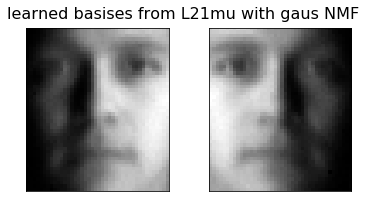

Acc = 0.0820 
NMI = 0.0874
The RRE for L21mu is 0.387806


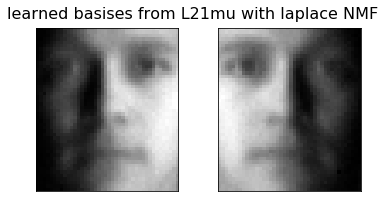

Acc = 0.0915 
NMI = 0.1060
The RRE for L1mu is 0.580547


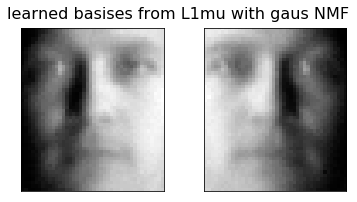

Acc = 0.0924 
NMI = 0.1151
The RRE for L1mu is 0.716510


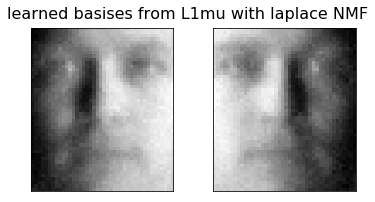

Acc = 0.0833 
NMI = 0.0858
The RRE for L2mu is 0.379423


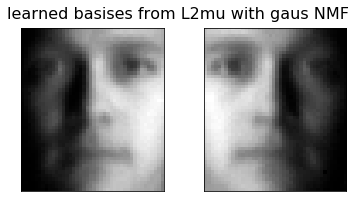

Acc = 0.0812 
NMI = 0.0884
The RRE for L2mu is 0.386197


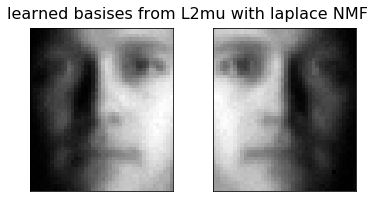

In [42]:
d ={}
P,Q = initialize(X)
steps = 100
V_hat = X
possible = [L21mu, L1mu,L2mu]
metrics = [L21mu,L1mu, L2mu]
noise_types = ['gaus', 'laplace']
for model in metrics:
    for n in noise_types:
        if model in possible:
            Vnoisy, noise = add_noise(X, n,40)
            Vnoisy = np.clip(Vnoisy,a_min=0,a_max=None)
            W, H = model(Vnoisy,P,Q,steps)
            RRE = np.linalg.norm(V_hat - W.dot(H.T)) / np.linalg.norm(V_hat)

            Y_pred = assign_cluster_label(H, Y)
            acc = accuracy_score(Y, Y_pred)
            nmi = normalized_mutual_info_score(Y, Y_pred)
            print('Acc = {:.4f} \nNMI = {:.4f}'.format(acc, nmi))

            plot_p(W, str(model).split()[1],n, RRE)
            
            key = str(model).split()[1]+'_'+n
            d[key]  = [W,H,n,RRE, acc, nmi]

In [43]:
d ={}
P,Q = initialize(X)
steps = 100
V_hat = X
possible = [L21mu, L1mu,L2mu]
metrics = [L21mu,L1mu, L2mu]
#noise_types = ['gaus', 'cauchy', 'laplace']
noise_types = ['gaus', 'gaus', 'gaus']
for i,model in enumerate(metrics):
    if model in possible:
        Vnoisy, noise = add_block(X,shape, 20)
        W, H = model(Vnoisy,P,Q,steps)
        Vnoisy = np.clip(Vnoisy,a_min=0,a_max=None)
        
        # Evaluations
        RRE = np.linalg.norm(V_hat - W.dot(H.T)) / np.linalg.norm(V_hat)
        #Y_pred = assign_cluster_label(W.dot(H.T), Y)
        #acc = accuracy_score(Y, Y_pred)
        #nmi = normalized_mutual_info_score(Y, Y_pred)

        key = str(model).split()[1]+'_'+n
        d[key]  = [W,H,n,RRE, acc, nmi]
        


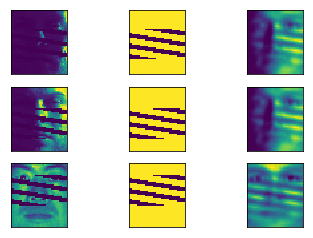

In [44]:
Vn = W.dot(H.T)
p = [Vnoisy, noise, Vn]
num_rows = 3

for row in range(num_rows):
    #for who in [10, 20 ,30]:
        for col, j in enumerate(p):
            r = row*40
            plt.subplot("".join(['33',str(num_rows*row+col+1)]))
            plt.imshow(j[:,r].reshape(48,42))
            plt.xticks(())
            plt.yticks(())
plt.show()

In [45]:
Y_pred = assign_cluster_label(H, Y)
acc = accuracy_score(Y, Y_pred)
nmi = normalized_mutual_info_score(Y, Y_pred)
print('Acc(NMI) = {:.4f} ({:.4f})'.format(acc, nmi))

Acc(NMI) = 0.0845 (0.0944)


In [46]:
print(tuple(d['L21mu_laplace'][-3:]))
print('RRE = {}, NMI = {}, Acc = {}'.format(d['L21mu_laplace'][-3],d['L21mu_laplace'][-2],d['L21mu_laplace'][-1]))


(0.45586690156094195, 0.0811930405965203, 0.08844929976047596)
RRE = 0.45586690156094195, NMI = 0.0811930405965203, Acc = 0.08844929976047596


In [122]:
f ={}
P,Q = initialize(X)
steps = 30
scale_range = 24
nruns = 5
V_hat = X
f = pd.DataFrame(columns = ['model','W','H','n','delta','RRE1','RRE2','RRE3','RRE4','RRE5','RRE_avg'])
possible = [L21mu, L1mu,L2mu]
metrics = [L21mu,L1mu, L2mu]
noise_types = ['gaus','laplace']

for model in metrics:
    for n in noise_types:
        for scale in range(4,scale_range,4):
        #for box_proportion in [0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
            #scale = shape[0]*box_proportion
            Vnoisy, noise = add_noise(X, n,scale)
            Vnoisy, noise = add_block(X,shape,int(scale))
            Vnoisy = np.clip(Vnoisy,a_min=0,a_max=None)
#            key = str(model).split()+'_'+str(scale)
#             f[key]  = {'W':W,'H':H,'n':n,'delta':scale,'RRE'+str(run):RRE}
            
            for run in range(nruns):
                W, H = model(Vnoisy,P,Q,steps)
                RRE = np.linalg.norm(V_hat - W.dot(H.T)) / np.linalg.norm(V_hat)
                if run==0:
                    f = f.append({'model':str(model).split()[1],'W':W,'H':H,'n':n,'delta':scale},ignore_index= True)
                f['RRE'+str(run+1)].iloc[-1] = RRE
     
        f['RRE_avg'].iloc[-1] = f[['RRE1','RRE2','RRE3','RRE4','RRE5']].iloc[-1].mean()
#             Y_pred = assign_cluster_label(H, Y)
#             acc = accuracy_score(Y, Y_pred)
#             nmi = normalized_mutual_info_score(Y, Y_pred)
#             print('Acc = {:.4f} \nNMI = {:.4f}'.format(acc, nmi))

#             plot_p(W, str(model).split()[1],n, RRE)
            
                
                
f.to_csv('rre.data.gl.ORL.csv')

In [117]:
f ={}
P,Q = initialize(X)
steps = 30
scale_range = 110
nruns = 5
V_hat = X
f = pd.DataFrame(columns = ['model','W','H','n','delta','RRE1','RRE2','RRE3','RRE4','RRE5','RRE_avg'])
possible = [L21mu, L1mu,L2mu]
metrics = [L21mu,L1mu, L2mu]
noise_types = ['gaus']

for model in metrics:
    #for scale in range(10,scale_range,10):
    for box_proportion in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
        #Vnoisy, noise = add_noise(X, n,scale)
        scale = shape*box_proportion
        Vnoisy, noise = add_sp(X,shape,)
        Vnoisy = np.clip(Vnoisy,a_min=0,a_max=None)
#            key = str(model).split()+'_'+str(scale)
#             f[key]  = {'W':W,'H':H,'n':n,'delta':scale,'RRE'+str(run):RRE}

        for run in range(nruns):
            W, H = model(Vnoisy,P,Q,steps)
            RRE = np.linalg.norm(V_hat - W.dot(H.T)) / np.linalg.norm(V_hat)
            if run==0:
                f = f.append({'model':str(model).split()[1],'W':W,'H':H,'n':n,'delta':box_proportion},ignore_index= True)
            f['RRE'+str(run+1)].iloc[-1] = RRE

    f['RRE_avg'].iloc[-1] = f[['RRE1','RRE2','RRE3','RRE4','RRE5']].iloc[-1].mean()
#             Y_pred = assign_cluster_label(H, Y)
#             acc = accuracy_score(Y, Y_pred)
#             nmi = normalized_mutual_info_score(Y, Y_pred)
#             print('Acc = {:.4f} \nNMI = {:.4f}'.format(acc, nmi))

#             plot_p(W, str(model).split()[1],n, RRE)

                
                
f.to_csv('rre.data.sparse.ORL.csv')



/home/taleni/.local/lib/python3.6/site-packages/pandas/core/indexing.py:189: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._setitem_with_indexer(indexer, value)


In [75]:
d = f[['model','delta', 'RRE1','RRE2','RRE3','RRE4','RRE5','RRE_avg']]
d['RRE_avg']=d.iloc[:,2:7].mean(axis=1)

In [93]:
f = d[['model','delta','RRE_avg']]


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
model,L21mu,L21mu,L21mu,L21mu,L21mu,L21mu,L21mu,L21mu,L21mu,L1mu,...,L1mu,L2mu,L2mu,L2mu,L2mu,L2mu,L2mu,L2mu,L2mu,L2mu
delta,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.1,...,0.9,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
RRE_avg,0.385323,0.417833,0.46651,0.527542,0.596395,0.670701,0.749711,0.831533,0.914662,0.726121,...,0.64731,0.384402,0.41684,0.465957,0.526619,0.595207,0.670063,0.74917,0.831123,0.914878


In [108]:
d.loc[d['model']=='L2mu']

,model,delta,RRE1,RRE2,RRE3,RRE4,RRE5,RRE_avg
18,L2mu,0.1,0.384402,0.384402,0.384402,0.384402,0.384402,0.384402
19,L2mu,0.2,0.416840,0.416840,0.416840,0.416840,0.416840,0.416840
20,L2mu,0.3,0.465957,0.465957,0.465957,0.465957,0.465957,0.465957
21,L2mu,0.4,0.526619,0.526619,0.526619,0.526619,0.526619,0.526619
22,L2mu,0.5,0.595207,0.595207,0.595207,0.595207,0.595207,0.595207
23,L2mu,0.6,0.670063,0.670063,0.670063,0.670063,0.670063,0.670063
24,L2mu,0.7,0.749170,0.749170,0.749170,0.749170,0.749170,0.749170
25,L2mu,0.8,0.831123,0.831123,0.831123,0.831123,0.831123,0.831123
26,L2mu,0.9,0.914878,0.914878,0.914878,0.914878,0.914878,0.914878


In [110]:
d.to_csv('rre.data.sparse.csv')

In [119]:
f.to_csv('rre.data.blocked.ORL.csv')

In [111]:
e = pd.DataFrame.from_csv('rre.data.blocked.csv')

/home/taleni/.local/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: from_csv is deprecated. Please use read_csv(...) instead. Note that some of the default arguments are different, so please refer to the documentation for from_csv when changing your function calls
  """Entry point for launching an IPython kernel.


In [113]:
d = e[['model','delta', 'RRE1','RRE2','RRE3','RRE4','RRE5','RRE_avg']]
d['RRE_avg']=d.iloc[:,2:7].mean(axis=1)

/home/taleni/.local/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


In [115]:
e

,model,W,H,n,delta,RRE1,RRE2,RRE3,RRE4,RRE5,RRE_avg
0,L21mu,[[5.85925279e-03 6.83522917e+01]\n [2.13604395...,[[6.24249227e-01 3.48438201e-07]\n [1.27086238...,gaus,2.1,0.373620,0.373620,0.373620,0.373620,0.373620,NaN
1,L21mu,[[5.88489289e-03 6.83744046e+01]\n [2.14567671...,[[6.27574335e-01 3.17671412e-07]\n [1.21777207...,gaus,4.2,0.373725,0.373725,0.373725,0.373725,0.373725,NaN
2,L21mu,[[8.49661671e-03 6.85081145e+01]\n [2.87315014...,[[6.21188495e-01 6.28531979e-07]\n [1.51356086...,gaus,8.4,0.375188,0.375188,0.375188,0.375188,0.375188,NaN
3,L21mu,[[8.02541376e-03 6.84849347e+01]\n [2.65302475...,[[6.12782930e-01 9.97188813e-07]\n [1.27262140...,gaus,12.6,0.382482,0.382482,0.382482,0.382482,0.382482,NaN
4,L21mu,[[1.10573371e-02 6.85276129e+01]\n [3.32629778...,[[6.19979322e-01 2.85783526e-07]\n [1.37893597...,gaus,16.8,0.404893,0.404893,0.404893,0.404893,0.404893,NaN
5,L21mu,[[1.49293952e-02 6.79830313e+01]\n [4.11032755...,[[6.30207355e-01 2.27324328e-07]\n [1.77868204...,gaus,21.0,0.472223,0.472223,0.472223,0.472223,0.472223,NaN
6,L21mu,[[nan nan]\n [nan nan]\n [nan nan]\n ...\n [na...,[[nan nan]\n [nan nan]\n [nan nan]\n ...\n [na...,gaus,25.2,NaN,NaN,NaN,NaN,NaN,NaN
7,L21mu,[[nan nan]\n [nan nan]\n [nan nan]\n ...\n [na...,[[nan nan]\n [nan nan]\n [nan nan]\n ...\n [na...,gaus,29.4,NaN,NaN,NaN,NaN,NaN,NaN
8,L21mu,[[nan nan]\n [nan nan]\n [nan nan]\n ...\n [na...,[[nan nan]\n [nan nan]\n [nan nan]\n ...\n [na...,gaus,33.6,NaN,NaN,NaN,NaN,NaN,NaN
9,L21mu,[[nan nan]\n [nan nan]\n [nan nan]\n ...\n [na...,[[nan nan]\n [nan nan]\n [nan nan]\n ...\n [na...,gaus,37.8,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for i in range(3):    
    plt.subplot('131')
    plt.imshow(X[:,i].reshape(48,42))
    plt.subplot('132')
    plt.imshow(aone_final[:,i].reshape(48,42))
    plt.subplot('133')
    plt.imshow(aX_final[:,i].reshape(48,42))
    plt.show()